<a href="https://colab.research.google.com/github/alexshtf/alexshtf.github.io/blob/power_spectrum_tridiag/assets/spectrum_power_tridiagonal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install -q -U fitstream

In [ ]:
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120

In [ ]:
import torch
print(torch.__version__)

2.10.0+cpu


# Tridiagonal speed

In [ ]:
import scipy.linalg as sla
import numpy as np

In [ ]:
M = np.random.randn(50, 100, 100)

In [ ]:
%%timeit -n 100 -r 30
sla.eigvalsh(M, subset_by_index=(50, 50)).sum()

20.5 ms ± 2.17 ms per loop (mean ± std. dev. of 30 runs, 100 loops each)


In [ ]:
%%timeit -n 100 -r 30
vals, vecs = sla.eigh(M, subset_by_index=(50, 50))
vecs.sum()

18.4 ms ± 1.76 ms per loop (mean ± std. dev. of 30 runs, 100 loops each)


In [ ]:
d = np.random.randn(50, 100)
e = np.random.randn(50, 99)

In [ ]:
%%timeit -n 100 -r 30
sla.eigvalsh_tridiagonal(d, e, select='i', select_range=(50, 50)).sum()

3.6 ms ± 31.2 µs per loop (mean ± std. dev. of 30 runs, 100 loops each)


In [ ]:
%%timeit -n 100 -r 30
vals, vecs = sla.eigh_tridiagonal(d, e, select='i', select_range=(50, 50))
vecs.sum()

4.77 ms ± 603 µs per loop (mean ± std. dev. of 30 runs, 100 loops each)


# Tridiagonal plotting

In [ ]:
def tridiagonal_eig_1d(k, diag, off_diag, xs):
    r"""Univariate matrix pencil eigenvalue.
        f(x) = \lambda_k(A + x B)
    where A and B are both tridiagonal.

    Args:
        k (int): the eigenvalue index
        diag (array): a 2 x n array of the diagonals of  A and B
        off_diag (array): a 2 x (n - 1) array of the off-diagonals of A and B
        xs (array): a vector of values x to evaluate f(x) at.

    Returns:
        An array y with y[i] = f(x[i])
    """

    padded_xs = np.c_[np.ones_like(xs), xs]
    mat_diag = padded_xs @ diag         # m x n
    mat_off_diag = padded_xs @ off_diag # m x (n - 1)
    eigval = sla.eigvalsh_tridiagonal(
        mat_diag, mat_off_diag, select='i', select_range=(k, k)
    )
    return eigval

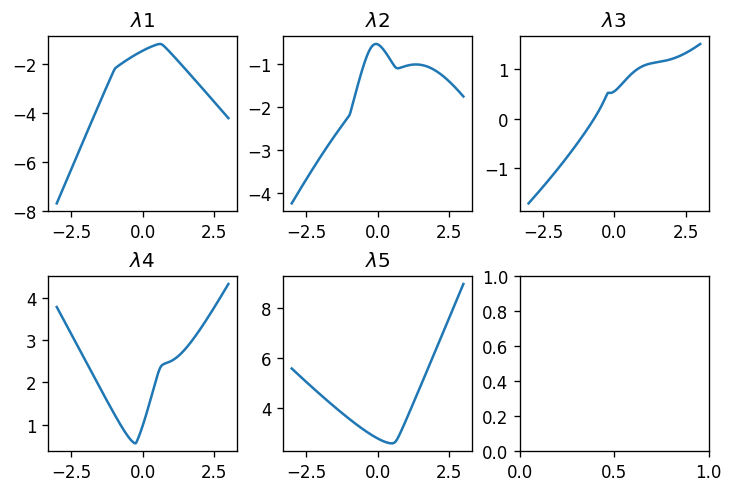

In [ ]:
import matplotlib.pyplot as plt
import math


def plot_tridiag_eig_1d(diag, off_diag, xmin=-3, xmax=3, resolution=1000, fn=tridiagonal_eig_1d):
    dim = diag.shape[1]
    n_rows = int(math.sqrt(dim))
    n_cols = int(math.ceil(dim / n_rows))
    xs = np.linspace(xmin, xmax, resolution)
    fig, axs = plt.subplots(n_rows, n_cols, layout='constrained', figsize=(2 * n_cols, 2 * n_rows))
    for i, ax in zip(range(dim), axs.ravel()):
        ax.plot(xs, fn(i, diag, off_diag, xs))
        ax.set_title(f'$\\lambda{1+i}$')
    fig.show()


np.random.seed(42)
plot_tridiag_eig_1d(np.random.randn(2, 5), np.random.randn(2, 4))

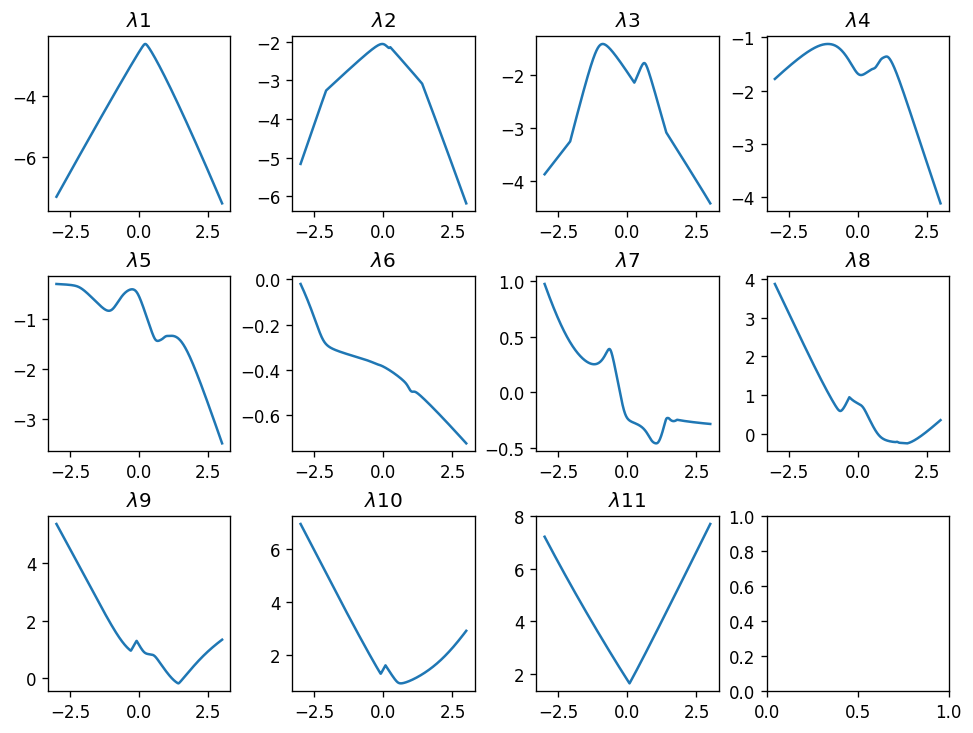

In [ ]:
plot_tridiag_eig_1d(np.random.randn(2, 11), np.random.randn(2, 10))

# The AutoGrad function

In [ ]:
class TridiagEigvalsh(torch.autograd.Function):
    @staticmethod
    def forward(ctx, diag: torch.Tensor, off_diag: torch.Tensor, k: int):
        """Eigenvalue of batch of tridiagonal matrices.

        Args:
            diag (tensor): A M1 x ... x Mn x N tensor representing a batch
                of size M1 x ... x Mn of diagonals of NxN tridiagonal symmetric
                matrices.
            off_diag (tensor): A M1 x ... x Mn x (N - 1) tensor representing
                a batch of size M1 x ... x Mn of off-diagonals of NxN
                tridiagonal symmetri cmatrices.
            k (int): The eigenvalue index
        """
        need_grad = ctx.needs_input_grad[0] or ctx.needs_input_grad[1]

        diag_np = diag.numpy()
        off_diag_np = off_diag.numpy()
        if need_grad:
            # k-th eigenvalue and eigenvector
            ws_np, Qs_np = sla.eigh_tridiagonal(
                diag_np, off_diag_np, select='i', select_range=(k, k),
                lapack_driver="stemr"
            )
            ws = torch.as_tensor(ws_np, dtype=diag.dtype)
            Qs = torch.as_tensor(Qs_np, dtype=diag.dtype)
            ctx.save_for_backward(Qs.squeeze(-1))
        else:
            # only k-th eigenvalue
            ws_cp = sla.eigvalsh_tridiagonal(
                diag_np, off_diag_np, select='i', select_range=(k, k)
            )
            ws = torch.as_tensor(ws_cp, dtype=diag.dtype)

        return ws.squeeze(-1) # k-th eigenvalue

    @staticmethod
    def backward(ctx, grad_w: torch.Tensor):
        (Qs,) = ctx.saved_tensors  # (..., N) from SciPy

        grad_w = grad_w.to(dtype=Qs.dtype)                 # (...)
        gw = grad_w.unsqueeze(-1)                          # (..., 1)

        grad_diag = gw * Qs.square()                       # (..., N)
        grad_off  = 2 * gw * (Qs[..., :-1] * Qs[..., 1:])  # (..., N-1)

        return grad_diag, grad_off, None

In [ ]:
diags = torch.randn(50, 100)
off_diags = torch.randn(50, 99)

In [ ]:
%%timeit -r 30 -n 100
w = TridiagEigvalsh.apply(diags, off_diags, 50).sum()

2.64 ms ± 78.7 µs per loop (mean ± std. dev. of 30 runs, 100 loops each)


In [ ]:
diags_param = torch.nn.Parameter(diags)
off_diags_param = torch.nn.Parameter(off_diags)

In [ ]:
%%timeit -r 30 -n 100
w = TridiagEigvalsh.apply(diags_param, off_diags_param, 2).sum()
w.backward()

3.25 ms ± 227 µs per loop (mean ± std. dev. of 30 runs, 100 loops each)


In [ ]:
def tridiag_eigvalsh(
        diag: torch.Tensor, off_diag: torch.Tensor, k: int
    ) -> torch.Tensor:
    return TridiagEigvalsh.apply(diag, off_diag, k)

# XOR demo

In [ ]:
from torch import nn

class TridiagSpectral(nn.Module):
    def __init__(self, *, num_features: int, dim: int, eig_idx: int):
        super().__init__()
        self.eig_idx = eig_idx
        self.diag = nn.Linear(num_features, dim)
        self.off_diag = nn.Linear(num_features, dim - 1)

    def forward(self, x):
        return tridiag_eigvalsh(self.diag(x), self.off_diag(x), self.eig_idx)

    def bias_params(self):
        return (self.diag.bias, self.off_diag.bias)

    def feat_params(self):
        return (self.diag.weight, self.off_diag.weight)

In [ ]:
def toy_function(x: torch.Tensor):
    return torch.maximum(
        x.sum(axis=-1) == 2,
        x.sum(axis=-1) == 5
    ).to(dtype=torch.float32)

In [ ]:
n_features = 12
X = torch.cartesian_prod(*([torch.tensor([0., 1.])] * n_features))
y = toy_function(X)

In [ ]:
torch.manual_seed(42)
train_mask = torch.rand(len(X)) < 0.5
X_train = X[train_mask, :]
y_train = y[train_mask]
X_test = X[~train_mask, :]
y_test = y[~train_mask]

X_train.shape

torch.Size([2051, 12])

In [ ]:
import fitstream as fts
from pprint import pprint

dim = 3
model = TridiagSpectral(num_features=n_features, dim=dim, eig_idx=dim // 2)
optim = torch.optim.Adam(model.parameters(), lr=1e-1)
events = fts.epoch_stream(
    (X_train, y_train), model, optim, nn.BCEWithLogitsLoss(), batch_size=32
)

for _, event in zip(range(3), events):
    pprint(event)
    print('---')

{'model': TridiagSpectral(
  (diag): Linear(in_features=12, out_features=3, bias=True)
  (off_diag): Linear(in_features=12, out_features=2, bias=True)
),
 'step': 1,
 'train_loss': 0.48179513216018677,
 'train_time_sec': 0.17859009099993273}
---
{'model': TridiagSpectral(
  (diag): Linear(in_features=12, out_features=3, bias=True)
  (off_diag): Linear(in_features=12, out_features=2, bias=True)
),
 'step': 2,
 'train_loss': 0.4430568218231201,
 'train_time_sec': 0.11284526400049799}
---
{'model': TridiagSpectral(
  (diag): Linear(in_features=12, out_features=3, bias=True)
  (off_diag): Linear(in_features=12, out_features=2, bias=True)
),
 'step': 3,
 'train_loss': 0.3672124743461609,
 'train_time_sec': 0.12090363399966009}
---


In [ ]:
import fitstream as fts
from pprint import pprint

dim = 3
model = TridiagSpectral(num_features=n_features, dim=dim, eig_idx=dim // 2)
optim = torch.optim.Adam(model.parameters(), lr=1e-1)
events = fts.epoch_stream(
    (X_train, y_train), model, optim, nn.BCEWithLogitsLoss(), batch_size=32
)

for _, event in zip(range(3), events):
    pprint(event)
    print('---')

{'model': TridiagSpectral(
  (diag): Linear(in_features=12, out_features=3, bias=True)
  (off_diag): Linear(in_features=12, out_features=2, bias=True)
),
 'step': 1,
 'train_loss': 0.4859733581542969,
 'train_time_sec': 0.11306098399927578}
---
{'model': TridiagSpectral(
  (diag): Linear(in_features=12, out_features=3, bias=True)
  (off_diag): Linear(in_features=12, out_features=2, bias=True)
),
 'step': 2,
 'train_loss': 0.4629446864128113,
 'train_time_sec': 0.11500376399999368}
---
{'model': TridiagSpectral(
  (diag): Linear(in_features=12, out_features=3, bias=True)
  (off_diag): Linear(in_features=12, out_features=2, bias=True)
),
 'step': 3,
 'train_loss': 0.4494847059249878,
 'train_time_sec': 0.11667310400025599}
---


In [ ]:
# define model and optimizer
dim = 3
model = TridiagSpectral(num_features=n_features, dim=dim, eig_idx=dim // 2)
optim = torch.optim.Adam(model.parameters(), lr=1e-1)

# pipe the epoch stream through the "take" transformation
events = fts.pipe(
    fts.epoch_stream(
        (X_train, y_train), model, optim, nn.BCEWithLogitsLoss(), batch_size=32
    ),
    fts.take(5)
)

for event in events:
    print(event['step'], event['train_loss'])

1 0.4958677887916565
2 0.4590296745300293
3 0.45743030309677124
4 0.46599212288856506
5 0.4613880515098572


In [ ]:
# define model and optimizer
dim = 3
model = TridiagSpectral(num_features=n_features, dim=dim, eig_idx=dim // 2)
optim = torch.optim.Adam(model.parameters(), lr=1e-1)

# pipe the epoch stream through the "take" transformation
events = fts.pipe(
    fts.epoch_stream(
        (X_train, y_train), model, optim, nn.BCEWithLogitsLoss(), batch_size=32
    ),
    fts.augment(lambda event: {"loss_squared": event["train_loss"] ** 2}),
    fts.take(5)
)

for event in events:
    print(event['step'], event["train_loss"], event['loss_squared'])

1 0.4833398759365082 0.23361743567031912
2 0.4570188522338867 0.20886623129717918
3 0.4375615417957306 0.1914601028586569
4 0.38786762952804565 0.15044129803570527
5 0.329280287027359 0.10842550742481993


In [ ]:
dim = 3
model = TridiagSpectral(num_features=n_features, dim=dim, eig_idx=dim // 2)
optim = torch.optim.Adam(model.parameters(), lr=1e-1)
events = fts.pipe(
    fts.epoch_stream(
        (X_train, y_train), model, optim, nn.BCEWithLogitsLoss(), batch_size=64
    ),
    fts.augment(fts.validation_loss((X_test, y_test), nn.BCEWithLogitsLoss())),
    fts.early_stop(key="val_loss", patience=5),
    fts.tap(fts.print_keys("train_loss", "val_loss"), every=10),
    fts.take(100)
)

In [ ]:
training_log = fts.collect_pd(events)

step=0001 train_loss=0.4917 val_loss=0.4564
step=0011 train_loss=0.3360 val_loss=0.3195
step=0021 train_loss=0.1515 val_loss=0.1597
step=0031 train_loss=0.0909 val_loss=0.1063
step=0041 train_loss=0.0590 val_loss=0.0850
step=0051 train_loss=0.0432 val_loss=0.0751
step=0061 train_loss=0.0349 val_loss=0.0701
step=0071 train_loss=0.0292 val_loss=0.0680
step=0081 train_loss=0.0256 val_loss=0.0667
step=0091 train_loss=0.0229 val_loss=0.0674


<Axes: title={'center': 'Dim = 3'}, xlabel='step'>

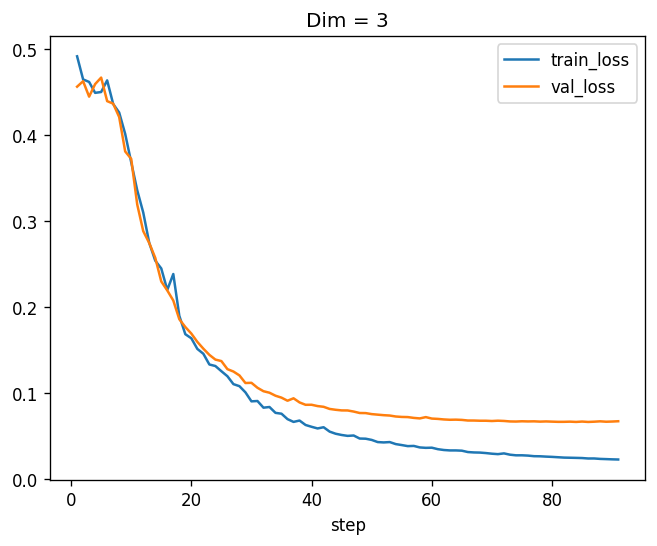

In [ ]:
training_log.plot(x="step", y=["train_loss", "val_loss"], title='Dim = 3')

In [ ]:
def run_experiment_bce(model, lr=1e-1, batch_size=64, max_epochs=100):
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    events = fts.pipe(
        fts.epoch_stream(
            (X_train, y_train), model, optim, nn.BCEWithLogitsLoss(), batch_size=batch_size
        ),
        fts.augment(fts.validation_loss((X_test, y_test), nn.BCEWithLogitsLoss())),
        fts.early_stop(key="val_loss", patience=5),
        fts.take(max_epochs)
    )
    return fts.collect_pd(events)

<Axes: title={'center': 'Dim = 5'}, xlabel='step'>

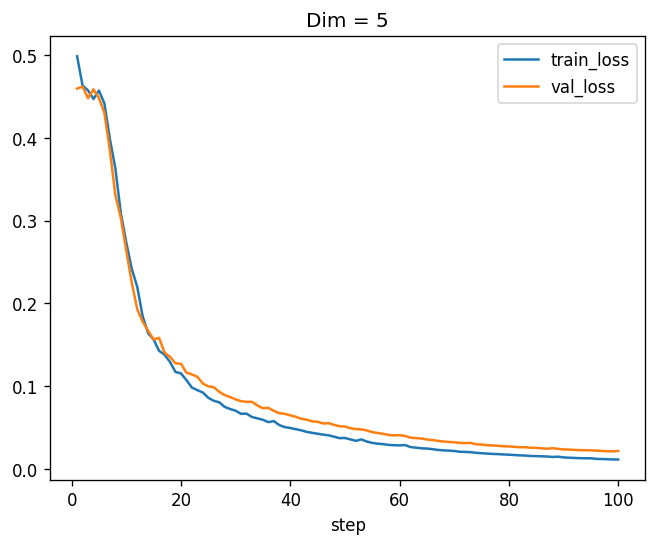

In [ ]:
training_log_5 = run_experiment_bce(
    TridiagSpectral(num_features=n_features, dim=5, eig_idx=2)
)
training_log_5.plot(x="step", y=["train_loss", "val_loss"], title='Dim = 5')

<Axes: title={'center': 'Dim = 9'}, xlabel='step'>

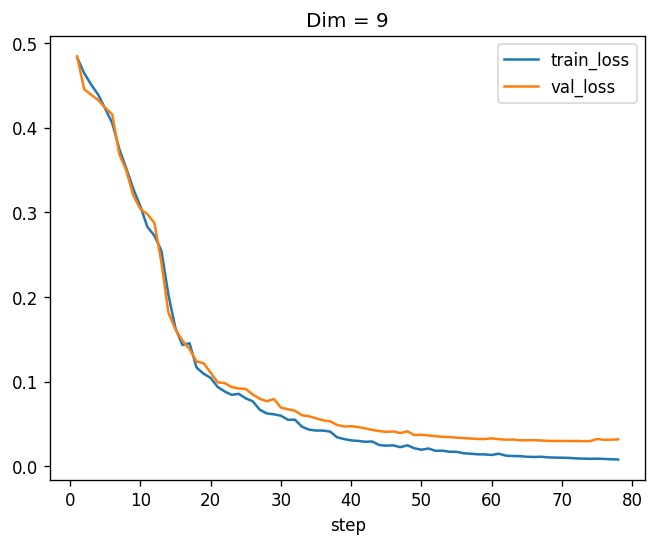

In [ ]:
training_log_9 = run_experiment_bce(
    TridiagSpectral(num_features=n_features, dim=9, eig_idx=4)
)
training_log_9.plot(x="step", y=["train_loss", "val_loss"], title='Dim = 9')

# California housing demo

## Prepartion - from previous post

In [ ]:
import pandas as pd

train_df = pd.read_csv('sample_data/california_housing_train.csv')
test_df = pd.read_csv('sample_data/california_housing_test.csv')

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error

xgb = XGBRegressor(random_state=42)
xgb.fit(
    train_df.drop('median_house_value', axis=1),
    train_df['median_house_value']
)

pred = xgb.predict(test_df.drop('median_house_value', axis=1))
xgboost_rmse = root_mean_squared_error(test_df['median_house_value'], pred)
print(f'XGBoost test RMSE = {xgboost_rmse:.2f}')

XGBoost test RMSE = 48023.99


In [ ]:
import numpy as np

skewed_columns = ['total_rooms', 'total_bedrooms', 'population', 'households']
train_df[skewed_columns] = train_df[skewed_columns].apply(np.log)
test_df[skewed_columns] = test_df[skewed_columns].apply(np.log)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform='pandas')
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

label_scale = float(scaler.scale_[-1])

In [ ]:
from torch import as_tensor

def to_tensors(df):
    target = 'median_house_value'
    return (
        as_tensor(df.drop(target, axis=1).values, dtype=torch.float32),
        as_tensor(df[target].values, dtype=torch.float32)
    )

X_train, y_train = to_tensors(train_scaled)
X_test, y_test = to_tensors(test_scaled)

num_features = X_train.shape[1]

## Training playground

In [ ]:
def scaled_rmse(y_true, y_pred):
    mse = nn.functional.mse_loss(y_pred, y_true)
    return torch.sqrt(mse) * label_scale

In [ ]:
from torch.optim.lr_scheduler import OneCycleLR

def complete_training_stream(
        dim, n_epochs, warmup_fraction=0.1, lr=5e-3, batch_size=64,
    ):
    model = TridiagSpectral(num_features=num_features, dim=dim, eig_idx=dim // 2)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    sched = OneCycleLR(optim, max_lr=lr, total_steps=n_epochs, pct_start=warmup_fraction, anneal_strategy='linear')

    epoch_events = fts.epoch_stream((X_train, y_train), model, optim, nn.MSELoss(), batch_size=batch_size)
    return fts.pipe(
        epoch_events,
        fts.take(n_epochs),
        fts.augment(fts.validation_loss((X_test, y_test), scaled_rmse)),
        fts.augment(lambda event: {"lr": optim.param_groups[0]['lr']}),
        fts.early_stop(key="val_loss", patience=n_epochs // 10),
        fts.tick(sched.step),
    )

In [ ]:
training_log = fts.collect_pd(complete_training_stream(11, 20))
print(training_log)

    step  train_loss  train_time_sec       val_loss            lr
0      1    1.073273        0.766501  112079.093750  2.000000e-04
1      2    0.476527        0.782601   68933.578125  5.000000e-03
2      3    0.322925        0.766536   65219.343750  4.722223e-03
3      4    0.293392        0.758102   63245.558594  4.444447e-03
4      5    0.278945        0.765792   61689.320312  4.166670e-03
5      6    0.268617        0.778063   61018.316406  3.888893e-03
6      7    0.259998        0.764847   60041.785156  3.611117e-03
7      8    0.255724        0.777118   60182.871094  3.333340e-03
8      9    0.252086        0.790681   59721.222656  3.055563e-03
9     10    0.247494        0.828679   59130.546875  2.777787e-03
10    11    0.245582        0.840544   59159.523438  2.500010e-03
11    12    0.243714        0.866996   59001.652344  2.222233e-03
12    13    0.241745        0.859632   58910.859375  1.944457e-03
13    14    0.239771        0.828692   58643.535156  1.666680e-03
14    15  

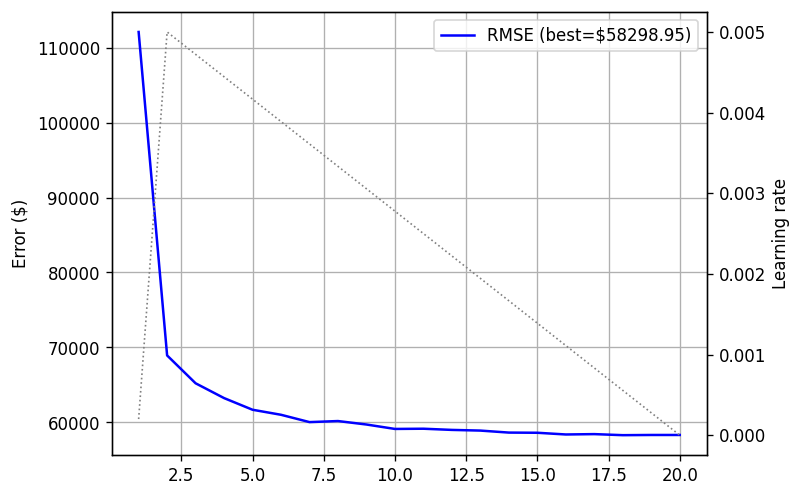

In [ ]:
def plot_log(log, title=None):
    fig, ax = plt.subplots()

    ax.plot(log.step, log.val_loss, color='blue',
            label=f'RMSE (best=${log.val_loss.min():.2f})')
    ax.set_ylabel("Error ($)")
    ax.grid()

    lr_ax = ax.twinx()
    lr_ax.plot(log.step, log.lr, label='Learning rate',
               color='gray', linestyle='dotted', linewidth=1)
    lr_ax.set_ylabel("Learning rate")

    ax.legend()
    if title is not None:
        ax.set_title(title)
    fig.show()

plot_log(training_log)

# Training with various matrix sizes

0it [00:00, ?it/s]

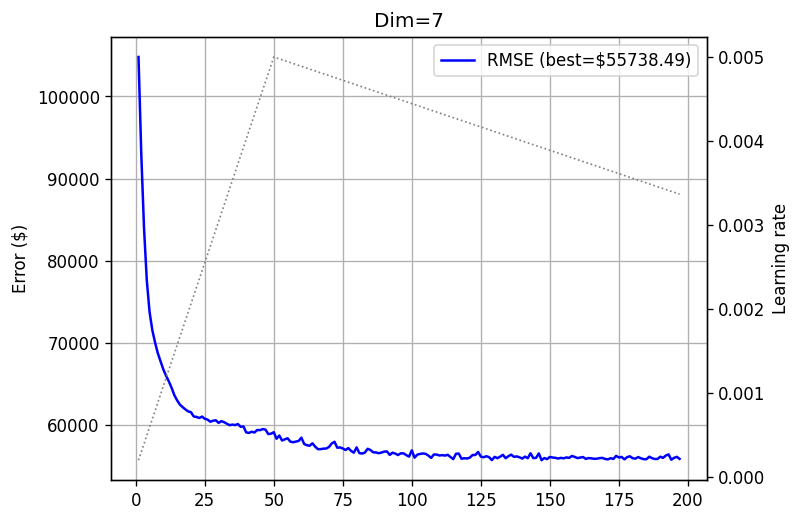

In [ ]:
from tqdm.notebook import tqdm

training_log_7 = fts.collect_pd(tqdm(complete_training_stream(7, 500)))
plot_log(training_log_7, title='Dim=7')

0it [00:00, ?it/s]

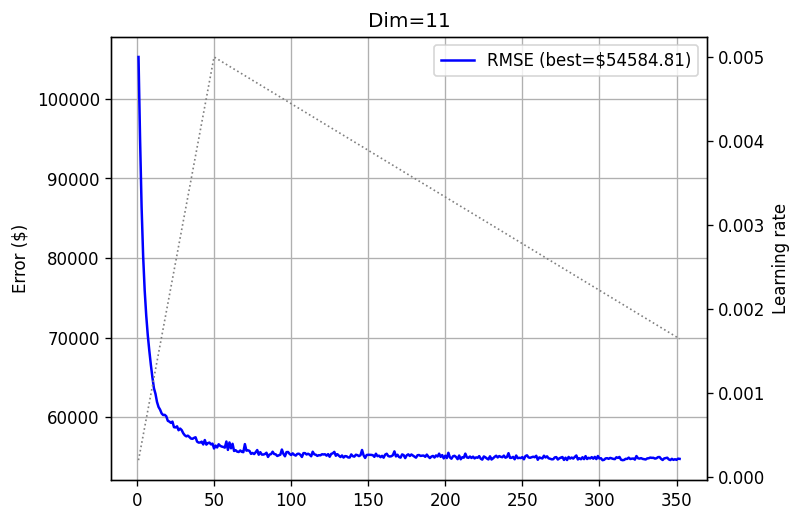

In [ ]:
from tqdm.notebook import tqdm


training_log_11 = fts.collect_pd(tqdm(complete_training_stream(11, 500)))
plot_log(training_log_11, title='Dim=11')

0it [00:00, ?it/s]

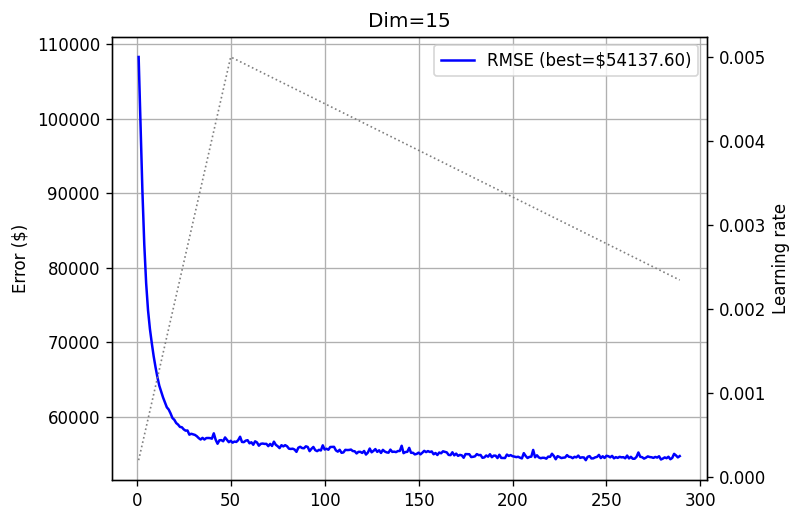

In [ ]:
training_log_15 = fts.collect_pd(tqdm(complete_training_stream(15, 500)))
plot_log(training_log_15, title='Dim=15')

0it [00:00, ?it/s]

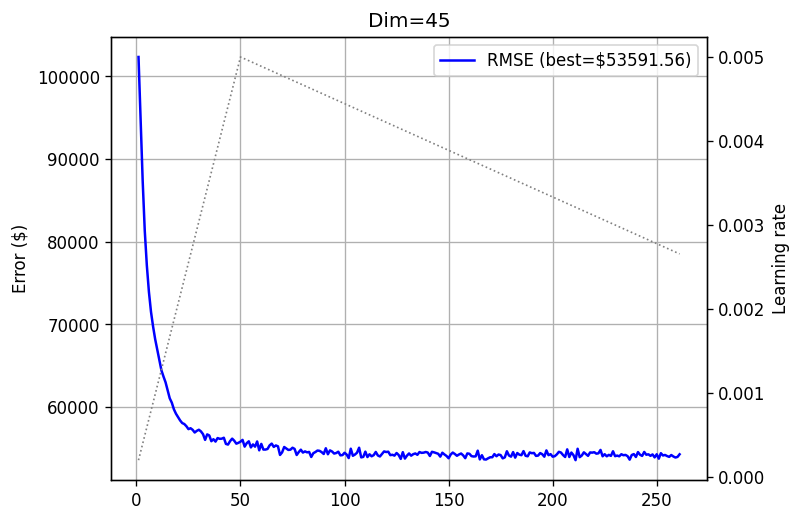

In [ ]:
training_log_45 = fts.collect_pd(tqdm(complete_training_stream(45, 500)))
plot_log(training_log_45, title='Dim=45')